In [ ]:
from s2gos_apps.processes.common import generation, simulation
from s2gos_apps.processes.pnp import generation_configs, simulation_configs

In [2]:
import numpy as np
import xarray as xr

In [5]:
srf = xr.load_dataset(
    "/home/gonzalezm/test/test2/s2gos-apps/extra_data/sentinel_2a-msi-6.nc"
)

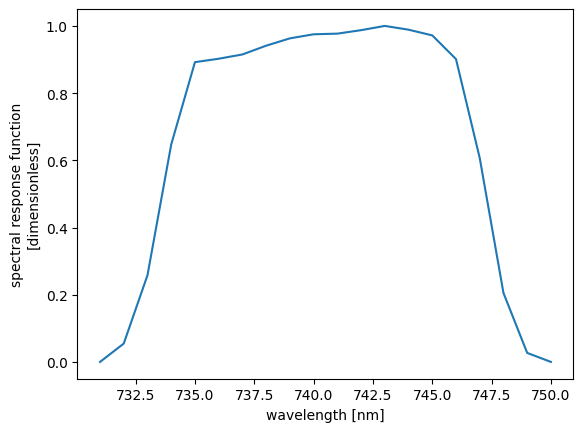

In [7]:
srf.srf.plot()

In [3]:
# np.unique(xr.load_dataset("/home/gonzalezm/test/test2/s2gos-apps/example/use_cases/gen_output/patagonia/data/landcover_patagonia_10.0m.zarr").landcover.values)
-72.4500, -46.9097

(-72.45, -46.9097)

In [4]:
scene_name = "patagonia"
target_lat = -46.9097
target_lon = -72.4500
target_size = 10
gmt_hour = 17
spp = 4

# expands the parameters passed to full configuration files for generation and simulation
gen_config_path = generation_configs(
    scene_name,
    target_lat,
    target_lon,
    target_size,
    random_seed=4,
    config_output_dir="./use_cases/gen_config",
    scene_output_dir="./use_cases/gen_output",
)

sim_config_path = simulation_configs(
    scene_name,
    target_lat,
    target_lon,
    target_size,
    gmt_hour,
    config_output_dir="./use_cases/sim_config",
    spp=spp,
)



Configuring generation...
Basic configuration created
Configuration validation passed
[mitsuba] Warning: Couldn't import the ipywidgets package. Installing this package is required for the system to properly log messages and print in Jupyter notebooks!


INFO:joseki.profiles.factory:Registering profile afgl_1986-tropical
INFO:joseki.profiles.factory:Registering profile afgl_1986-midlatitude_summer
INFO:joseki.profiles.factory:Registering profile afgl_1986-midlatitude_winter
INFO:joseki.profiles.factory:Registering profile afgl_1986-subarctic_summer
INFO:joseki.profiles.factory:Registering profile afgl_1986-subarctic_winter
INFO:joseki.profiles.factory:Registering profile afgl_1986-us_standard
INFO:joseki.profiles.factory:Registering profile mipas_2007-midlatitude_day
INFO:joseki.profiles.factory:Registering profile mipas_2007-midlatitude_night
INFO:joseki.profiles.factory:Registering profile mipas_2007-polar_summer
INFO:joseki.profiles.factory:Registering profile mipas_2007-polar_winter
INFO:joseki.profiles.factory:Registering profile mipas_2007-tropical
INFO:joseki.profiles.factory:Registering profile ussa_1976
/home/gonzalezm/test/test2/s2gos-apps/.pixi/envs/default/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress



Configuring simulation...
Simulation configured:
  Sensors: 1
    1. uav_rgb_camera_hyp (uav/perspective_camera)
  Saved: simulation_config.json


In [5]:
# generate the 3D scene description from the generation config
scene_description_path = generation.generation(gen_config_path)

INFO:root:Importing assets from XML: /home/gonzalezm/test/test2/s2gos-apps/extra_data/only_tower_v0_1.xml
INFO:root:Parsed /home/gonzalezm/test/test2/s2gos-apps/extra_data/only_tower_v0_1.xml: found 2 materials and 2 shapes
INFO:root:Successfully converted 2 materials from XML
INFO:root:Successfully imported 2 assets from /home/gonzalezm/test/test2/s2gos-apps/extra_data/only_tower_v0_1.xml
INFO:root:Registered 12 resources:
INFO:root:  Core (6): aoi, target_dem, target_landcover, target_mesh, target_texture, scene_description
INFO:root:  Buffer (5): buffer_aoi, buffer_dem, buffer_landcover, buffer_mesh, buffer_texture
INFO:root:  Optional (1): user_assets
INFO:root:Pipeline initialized for scene 'patagonia'
INFO:root:Pipeline visualization saved to: use_cases/gen_output/patagonia/patagonia_dag.png
INFO:root:Random seed set to 4 for reproducible generation
INFO:root:AOI corners (lon, lat):
INFO:root:  Corner 1: (-46.954658, -72.515685)
INFO:root:  Corner 2: (-46.954658, -72.384315)
INFO



Generating scene description...
Configuration validation

Configuration Summary:
  Scene: patagonia
  Location: -46.9097°, -72.4500°
  AOI: 10.0 km²
  Resolution: 10.0 m
Generating scene with configuration

Generating DAG visualization
DAG saved to: use_cases/gen_output/patagonia/patagonia_dag.png

Resource execution order:
  aoi (depends on: none)
  target_dem (depends on: ['aoi'])
  target_landcover (depends on: ['aoi'])
  target_mesh (depends on: ['target_dem'])
  target_texture (depends on: ['target_landcover'])
  buffer_aoi (depends on: ['aoi'])
  buffer_dem (depends on: ['buffer_aoi'])
  buffer_landcover (depends on: ['buffer_aoi'])
  buffer_mesh (depends on: ['buffer_dem'])
  buffer_texture (depends on: ['buffer_landcover'])
  user_assets (depends on: ['target_dem'])
  scene_description (depends on: ['target_mesh', 'target_texture', 'buffer_mesh', 'buffer_texture', 'user_assets'])


INFO:root:DEM saved to use_cases/gen_output/patagonia/data/dem_patagonia_10.0m.zarr
INFO:root:Target DEM: use_cases/gen_output/patagonia/data/dem_patagonia_10.0m.zarr
INFO:root:ESA Worldcover 2021 saved to use_cases/gen_output/patagonia/data/landcover_patagonia_10.0m.zarr
INFO:root:Target landcover (10.0m): use_cases/gen_output/patagonia/data/landcover_patagonia_10.0m.zarr
INFO:root:Mesh saved to use_cases/gen_output/patagonia/meshes/patagonia_terrain.ply
INFO:root:Target mesh: use_cases/gen_output/patagonia/meshes/patagonia_terrain.ply
INFO:root:Texture: use_cases/gen_output/patagonia/textures/patagonia_10.0m_selection.png
INFO:root:Target texture: use_cases/gen_output/patagonia/textures/patagonia_10.0m_selection.png
INFO:root:DEM saved to use_cases/gen_output/patagonia/data/dem_buffer_patagonia_60.0m.zarr
INFO:root:ESA Worldcover 2021 saved to use_cases/gen_output/patagonia/data/landcover_buffer_patagonia_60.0m.zarr
INFO:root:Buffer landcover (60.0m): use_cases/gen_output/patagonia/d

Scene generated successfully!
 Location: -46.9097, -72.45
 Target: 10.0km² at 10.0m
  Buffer: 60.0km at 60.0m
  Output: use_cases/gen_output/patagonia

Output directory: use_cases/gen_output/patagonia
<class 's2gos_utils.io.paths.PathRef'>
patagonia.yml


In [6]:
from s2gos_utils import SceneDescription

scene = SceneDescription.load_yaml(scene_description_path)

In [7]:
scene.objects

[{'blender_fix': True,
  'face_normals': True,
  'id': 'only_tower_v0_1_only_main_tower',
  'material': 'mat_metal',
  'mesh': 'objects/only_tower_v0_1_only_main_tower.ply',
  'position': [-220.0, 850.0, 823.2709732068414],
  'rotation': [90.0, 0.0, 0.0],
  'scale': 1.0},
 {'blender_fix': True,
  'face_normals': True,
  'id': 'only_tower_v0_1_only_fixed_hypernets_001_tower',
  'material': 'mat_metal',
  'mesh': 'objects/only_tower_v0_1_only_fixed_hypernets_001_tower.ply',
  'position': [-220.0, 850.0, 823.2709732068414],
  'rotation': [90.0, 0.0, 0.0],
  'scale': 1.0}]

In [8]:
# simulate an observation from the scene description and simulation config
simulation_output_dire = simulation.simulation(
    f"./use_cases/gen_output/{scene_name}/{scene_name}.yml",
    sim_config_path,
    f"./use_cases/sim_output/{scene_name}",
)

INFO:root:Successfully loaded spectral data: /home/gonzalezm/test/test2/s2gos-apps/packages/s2gos-generator/resources/data/spectra/spectrum_baresoil_high.nc (variable: reflectance)
INFO:root:Successfully loaded spectral data: /home/gonzalezm/test/test2/s2gos-apps/packages/s2gos-generator/resources/data/spectra/spectrum_concrete.nc (variable: reflectance)
INFO:root:Successfully loaded spectral data: /home/gonzalezm/test/test2/s2gos-apps/packages/s2gos-generator/resources/data/spectra/spectrum_cropland_foliage_uniform.nc (variable: reflectance)
INFO:root:Successfully loaded spectral data: /home/gonzalezm/test/test2/s2gos-apps/packages/s2gos-generator/resources/data/spectra/spectrum_cropland_foliage_uniform.nc (variable: transmittance)
INFO:root:Using uniform RGB value: [0.5, 0.5, 0.5]
INFO:root:Successfully loaded spectral data: /home/gonzalezm/test/test2/s2gos-apps/packages/s2gos-generator/resources/data/spectra/grass_averaged.nc (variable: reflectance)
INFO:root:Successfully loaded spe



Simulating observation...

Validating materials and running simulation...
Using SceneDescription object for validation...
Available materials: ['baresoil', 'concrete', 'cropland', 'default_bsdf', 'grassland', 'mangroves', 'mat_metal', 'moss', 'rough_aluminum', 'shrubland', 'snow', 'treecover', 'water', 'wetland']
✅ All 2 object material references are valid
Using SceneDescription object for simulation
Eradiate simulation: config_simulation
  Sensors: 1
  Measurements: 0

Workflow: Standard


INFO:joseki.core:Creating profile afgl_1986-us_standard
INFO:joseki.profiles.schema:Dataset is valid
INFO:s2gos_simulator.backends.eradiate.sensor_translator:Resolved 'only_tower_v0_1.xml' to 'only_tower_v0_1_only_fixed_hypernets_001_tower' (first of 2 matches)
INFO:root:Material validation passed - no issues found
INFO:joseki.profiles.schema:Dataset is valid
INFO:eradiate.experiments._core:Initializing kernel scene
INFO:joseki.profiles.schema:Dataset is valid


measures =[{'id': 'uav_rgb_camera_hyp', 'spp': 4, 'srf': {'type': 'multi_delta', 'wavelengths': [440.0, 550.0, 660.0]}, 'origin': [-219.980526, 858.30517, 931.6233232068414], 'type': 'perspective', 'fov': 40.0, 'film_resolution': [2000, 2000], 'target': [-219.980526, 858.30517, 823.2709732068414], 'up': [0.0, 1.0, 0.0]}]
  Measure 1/1: uav_rgb_camera_hyp


INFO:eradiate.experiments._core:Launching simulation
Eradiate [660 nm]: 3/3|██████████| 00:15, ETA=00:00
INFO:eradiate.experiments._core:Post-processing results


RGB image saved to: use_cases/sim_output/patagonia/uav_rgb_camera_hyp_rgb.png
Processing 1 measure results...
Measure 'uav_rgb_camera_hyp' saved to use_cases/sim_output/patagonia/config_simulation_uav_rgb_camera_hyp.zarr
Simulation completed successfully!

Output directory: ./use_cases/sim_output/patagonia


In [9]:
test = xr.load_dataset(
    "/home/gonzalezm/test/test2/s2gos-apps/example/sim_output/patagonia/config_simulation_hypstar_series_test.zarr"
)

/home/gonzalezm/test/test2/s2gos-apps/.pixi/envs/default/lib/python3.11/site-packages/xarray/backends/api.py:651: RuntimeWarning: 'netcdf4' fails while guessing
  engine = plugins.guess_engine(filename_or_obj)
/home/gonzalezm/test/test2/s2gos-apps/.pixi/envs/default/lib/python3.11/site-packages/xarray/backends/api.py:651: RuntimeWarning: 'scipy' fails while guessing
  engine = plugins.guess_engine(filename_or_obj)


In [10]:
test_raw = xr.load_dataset(
    "/home/gonzalezm/test/test2/s2gos-apps/example/sim_output/patagonia/config_simulation_hypstar_series_test_raw_eradiate.zarr"
)

In [11]:
test_raw

<xarray.Dataset> Size: 4MB
Dimensions:     (w: 131, sza: 1, saa: 1, y_index: 64, x_index: 64)
Coordinates:
    bin_wmax    (w) float64 1kB 385.0 395.0 405.0 ... 1.675e+03 1.685e+03
    bin_wmin    (w) float64 1kB 375.0 385.0 395.0 ... 1.665e+03 1.675e+03
  * saa         (saa) float64 8B 355.2
  * sza         (sza) float64 8B 62.2
  * w           (w) float64 1kB 380.0 390.0 400.0 ... 1.66e+03 1.67e+03 1.68e+03
    x           (x_index) float64 512B 0.0 0.01587 0.03175 ... 0.9683 0.9841 1.0
  * x_index     (x_index) int64 512B 0 1 2 3 4 5 6 7 ... 56 57 58 59 60 61 62 63
    y           (y_index) float64 512B 0.0 0.01587 0.03175 ... 0.9683 0.9841 1.0
  * y_index     (y_index) int64 512B 0 1 2 3 4 5 6 7 ... 56 57 58 59 60 61 62 63
Data variables:
    irradiance  (sza, saa, w) float64 1kB 0.5159 0.5839 ... 0.1019 0.09623
    radiance    (w, y_index, x_index, saa, sza) float64 4MB 0.005042 ... 0.00...
Attributes:
    backend:            eradiate
    created_at:         2026-01-13T17:32:53.381009
    description:        Simulation using scene configuration with both sensor...
    illumination_type:  directional
    measurement_types:  []
    num_measurements:   0
    num_sensors:        1
    output_dir:         use_cases/sim_output/patagonia
    sensor_id:          hypstar_series_test_raw_eradiate
    sensor_types:       ['ground']
    simulation_name:    config_simulation

In [12]:
cams = xr.load_dataset(
    "/home/gonzalezm/test/tapu/notebooks/output_new/PNP/timeseries_ms_2020-06-21_v1.nc"
)

In [13]:
cams.where(cams.z > 0.8, drop=True)

<xarray.Dataset> Size: 305kB
Dimensions:  (time: 1, lon: 1, lat: 1, z: 1192)
Coordinates:
  * time     (time) datetime64[ns] 8B 2020-06-21T12:00:00
  * lon      (lon) float64 8B -72.45
  * lat      (lat) float64 8B -46.91
  * z        (z) float64 10kB 0.9 1.0 1.1 1.2 1.3 ... 119.7 119.8 119.9 120.0
Data variables: (12/31)
    p        (time, lon, lat, z) float64 10kB 8.973e+04 8.863e+04 ... 0.00254
    t        (time, lon, lat, z) float64 10kB 272.4 272.1 272.2 ... 358.8 360.0
    x_H2O    (time, lon, lat, z) float64 10kB 0.007283 0.007087 ... 2.335e-07
    x_O3     (time, lon, lat, z) float64 10kB 2.096e-08 2.96e-08 ... 5e-10
    x_N2O    (time, lon, lat, z) float64 10kB 3.2e-07 3.2e-07 ... 1.85e-10
    x_CO     (time, lon, lat, z) float64 10kB 6.364e-08 6.163e-08 ... 5e-05
    ...       ...
    x_CH3Cl  (time, lon, lat, z) float64 10kB 6.73e-10 6.7e-10 ... 3.56e-13
    x_H2O2   (time, lon, lat, z) float64 10kB 1.955e-10 1.95e-10 ... 1e-15
    x_C2H2   (time, lon, lat, z) float64 10kB 1.848e-10 1.72e-10 ... 6.32e-16
    x_C2H6   (time, lon, lat, z) float64 10kB 2e-09 2e-09 ... 2.191e-15 2.19e-15
    x_PH3    (time, lon, lat, z) float64 10kB 1e-20 1e-20 1e-20 ... 1e-20 1e-20
    n        (time, lon, lat, z) float64 10kB 2.386e+25 2.359e+25 ... 5.11e+17
Attributes:
    Conventions:  
    title:        
    institution:  
    source:       
    history:      
    references:   
    url:          
    urldate:

In [14]:
cams_12 = xr.load_dataset(
    "/home/gonzalezm/test/tapu/notebooks/output_new/PNP/timeseries_ms_2020-12-21_v1.nc"
)
# cams_12.where(cams.z > 0.8, drop=True)
cams

<xarray.Dataset> Size: 307kB
Dimensions:  (time: 1, lon: 1, lat: 1, z: 1201)
Coordinates:
  * time     (time) datetime64[ns] 8B 2020-06-21T12:00:00
  * lon      (lon) float64 8B -72.45
  * lat      (lat) float64 8B -46.91
  * z        (z) float64 10kB 0.0 0.1 0.2 0.3 0.4 ... 119.7 119.8 119.9 120.0
Data variables: (12/31)
    p        (time, lon, lat, z) float64 10kB 1.013e+05 1.002e+05 ... 0.00254
    t        (time, lon, lat, z) float64 10kB 288.2 287.6 286.9 ... 358.8 360.0
    x_H2O    (time, lon, lat, z) float64 10kB 0.009049 0.008853 ... 2.335e-07
    x_O3     (time, lon, lat, z) float64 10kB 2.66e-08 2.687e-08 ... 5e-10
    x_N2O    (time, lon, lat, z) float64 10kB 3.2e-07 3.2e-07 ... 1.85e-10
    x_CO     (time, lon, lat, z) float64 10kB 1.5e-07 1.495e-07 ... 5e-05
    ...       ...
    x_CH3Cl  (time, lon, lat, z) float64 10kB 7e-10 6.97e-10 ... 3.56e-13
    x_H2O2   (time, lon, lat, z) float64 10kB 2e-10 1.995e-10 ... 1.18e-15 1e-15
    x_C2H2   (time, lon, lat, z) float64 10kB 3e-10 2.872e-10 ... 6.32e-16
    x_C2H6   (time, lon, lat, z) float64 10kB 2e-09 2e-09 ... 2.191e-15 2.19e-15
    x_PH3    (time, lon, lat, z) float64 10kB 1e-20 1e-20 1e-20 ... 1e-20 1e-20
    n        (time, lon, lat, z) float64 10kB 2.546e+25 2.523e+25 ... 5.11e+17
Attributes:
    Conventions:  
    title:        
    institution:  
    source:       
    history:      
    references:   
    url:          
    urldate:

In [15]:
import matplotlib.pyplot as plt

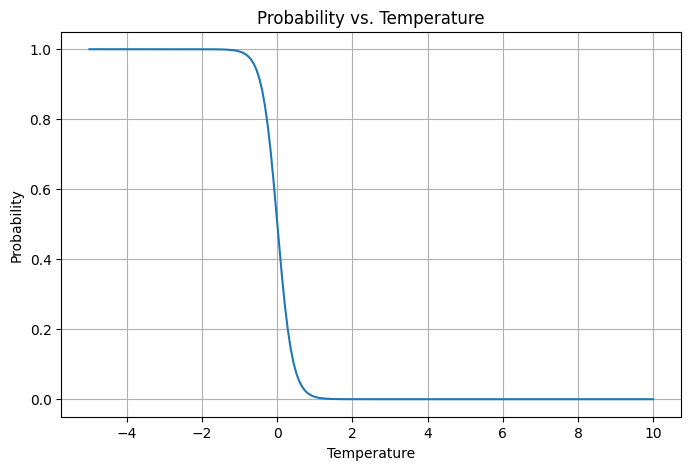

In [16]:
T_C = 0.0  # 50% rain-snow transition temperature (°C)
SIGMA = 0.2  # Logistic function width (°C)
HARD_FREEZE_LIMIT = 0.4  # Temperature above which snow is impossible (°C)

# Define the range of temperatures to plot
temps = np.linspace(-5, 10, 200)

# Calculate the function
probabilities = 1.0 / (1.0 + np.exp((temps - T_C) / SIGMA))

# Plot the results
plt.figure(figsize=(8, 5))
plt.plot(temps, probabilities)
plt.title("Probability vs. Temperature")
plt.xlabel("Temperature")
plt.ylabel("Probability")
plt.grid(True)
plt.show()

In [18]:
import pickle

import numpy as np
import shapely
import xarray as xr

In [19]:
with open("test.pkl", "rb") as f:  # open a text file
    exclusion = pickle.load(f)

In [20]:
geometry = exclusion[0]["geometry"]

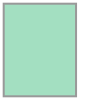

In [21]:
geometry

In [22]:
print(geometry.centroid)

POINT (-220 850)


In [23]:
geometry.contains(shapely.Point(0, 0))

False

In [24]:
print(geometry.centroid)

POINT (-220 850)


In [25]:
3027258.1541947043 - 3026258.1541947043

1000.0

In [26]:
from s2gos_utils.coordinates import CoordinateSystem

In [27]:
target_lat = -46.9097
target_lon = -72.4500
coords = CoordinateSystem(target_lat, target_lon)

In [28]:
lat, lon = (-46.900864, -72.452897)
x, y = coords.latlon_to_scene(lon, lat)
print(x, y)

836396.6577689981 -3026758.1541947043


In [29]:
print(shapely.Point(x, y).buffer(500).centroid)

POINT (836396.657768998 -3026758.1541947033)
